In [3]:
import pandas as pd
import pickle
import numpy as np
import copy
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns

from _helper_functions import *


In [21]:
mpradf=pd.read_pickle('supp/endf.rescaledPctl_45_85.wtcollapsed.sumRnaDivSumDna-repSum.pd.df.pickle').set_index('enhancer-sites')
mpradf.head(1)

,enhancer-id,wt-enhancer-seq,wt-control-name,wt-control-label,wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,abl-enhancer-seq,abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,act-change-bin,enhancer-dependent-gata-ets
enhancer-sites,,,,,,,,,
S1-G1R-S2-E1F-S3-E2F-S4-G2R-S5-G3F-S6,OLS:0,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,OLS WT,Neural,1.197798,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.848065,"(1, 0)",0


In [4]:
fn='supp/OLSName2SyntaxFamily-vary-aff.pydict.pickle'
with open(fn,'rb') as f:
    OLSName2SyntaxFamily=pickle.load(f)
    
fn='supp/SyntaxFamily2OLSName-vary-aff.pydict.pickle'
with open(fn,'rb') as f:
    SyntaxFamily2OLSName=pickle.load(f)

fn='supp/OLSEnSeq2Name.pydict.pickle'
with open(fn,'rb') as f:
    OLSEnSeq2Sites=pickle.load(f)

OLSSites2Seq={sites:seq for seq,sites in OLSEnSeq2Sites.items()}


In [16]:
mpradf['site_index'] = mpradf['wt-enhancer-seq'].map(OLSEnSeq2Sites)

In [18]:
mpradf.set_index('site_index', inplace=True)

/var/folders/5z/t9ftk7ds7890nc05pq3sr3fc0000gn/T/ipykernel_5107/913986800.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Otx-a\nSyntax Family','Robust\nSyntax Family\n(Microscsope)','Inert\nSyntax Family\n(Microscsope)'],size=7)


[Text(0, 0, 'Otx-a\nSyntax Family'),
 Text(1, 0, 'Robust\nSyntax Family\n(Microscsope)'),
 Text(2, 0, 'Inert\nSyntax Family\n(Microscsope)')]

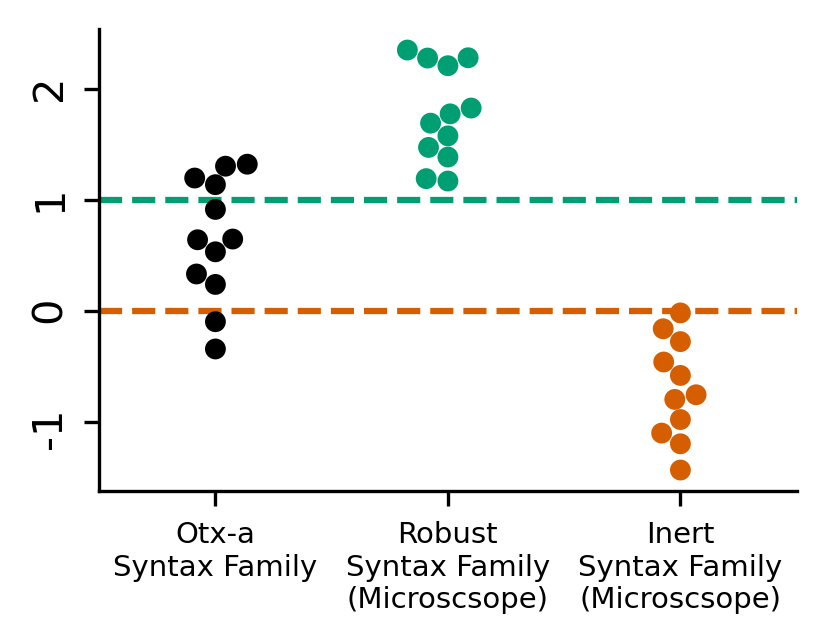

In [19]:
##############################
# from microscope variatns already tested
##############################

otxaSyntax='L1-GR-L2-EF-L3-EF-L4-GR-L5-GF-L6'
funcSyntax='L1-GR-L5-ER-L2-GR-L4-GR-L3-EF-L6' 
inertSyntax='L5-ER-L3-GF-L2-GR-L1-ER-L4-GR-L6' 

data=[]
for synfam in [otxaSyntax,funcSyntax,inertSyntax]:
    
    actList=[]
    for sites in SyntaxFamily2OLSName[synfam]:

        if sites not in mpradf.index: continue
        act=mpradf.at[sites,'wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled']
        actList.append(act)
        
    data.append(actList)

fig,ax=plt.subplots(1,figsize=(3,2),dpi=300)

sns.swarmplot(data=data,palette=['black',cb['green'],cb['red']])

ax.axhline(0,ls='--',color=cb['red'],  lw=1.5)
ax.axhline(1,ls='--',color=cb['green'],lw=1.5)

yticks=[-1,0,1,2]
ax.set_yticks(yticks)
ax.set_yticklabels(yticks,rotation=90)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticklabels(['Otx-a\nSyntax Family','Robust\nSyntax Family\n(Microscsope)','Inert\nSyntax Family\n(Microscsope)'],size=7)
